# XGBoost Model with Bayesian Optimization: Smoking and Socioeconomic Predictors Only

## Purpose
This notebook trains a single XGBoost regression model to predict lung cancer mortality using only smoking, socioeconomic, and demographic predictors.

The notebook follows the same modeling pipeline as notebook 09:
- **Bayesian hyperparameter optimization** with BayesSearchCV
- **County-level grouped train/test split** to prevent data leakage
- **Permutation importance and SHAP** for model interpretation
- **Publication-ready figures** saved to a separate output folder

This analysis is intended to provide a direct comparison against the 45-predictor model from notebook 09, so the incremental value of the atmospheric predictor block can be assessed explicitly.


## 1. Import Libraries and Setup

In [1]:
# Core libraries
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import xgboost as xgb

from scipy.stats import probplot
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from skopt import BayesSearchCV
from skopt.space import Integer, Real

warnings.filterwarnings('ignore')


## 2. Configuration and Output Setup


In [2]:
# Create output directory for publication figures
output_dir = '../data/outputs/modeling/xgboost_smoking_ses/'
os.makedirs(output_dir, exist_ok=True)

# MDPI journal figure specifications
SINGLE_COL_WIDTH = 3.27
DOUBLE_COL_WIDTH = 6.85
DPI = 600
FONT_SIZE = 11
INTERPRETATION_EXCLUDE = {'is_post_2015'}

# Set plotting style
plt.rcParams['font.size'] = FONT_SIZE
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['grid.color'] = '#E2E8F0'
plt.rcParams['grid.linewidth'] = 0.7
plt.rcParams['grid.alpha'] = 0.45
plt.rcParams['axes.labelcolor'] = '#1F2937'
plt.rcParams['xtick.color'] = '#1F2937'
plt.rcParams['ytick.color'] = '#1F2937'
sns.set_palette(['#0072B2', '#D55E00', '#D946EF'])

TRAIN_COLOR = '#0072B2'
TEST_COLOR = '#D55E00'
REF_LINE_COLOR = '#374151'
ANNOTATION_FACE = '#F8FAFC'
ANNOTATION_EDGE = '#CBD5E1'
TITLE_COLOR = '#1F2937'


def get_interpretation_mask(feature_names):
    feature_names = list(feature_names)
    return np.array([feature not in INTERPRETATION_EXCLUDE for feature in feature_names], dtype=bool)


def style_prediction_scatter(y_train, train_predictions, y_test, test_predictions,
                             train_r2, train_rmse, test_r2, test_rmse,
                             title, filename, figure_note):
    fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH * 1.12, DOUBLE_COL_WIDTH * 0.82))

    all_values = np.concatenate([
        np.asarray(y_train), np.asarray(train_predictions),
        np.asarray(y_test), np.asarray(test_predictions)
    ])
    value_min = all_values.min()
    value_max = all_values.max()
    pad = (value_max - value_min) * 0.05
    lims = (value_min - pad, value_max + pad)

    ax.scatter(y_train, train_predictions, s=24, alpha=0.26, c=TRAIN_COLOR,
               edgecolors='white', linewidths=0.35, label='Train')
    ax.scatter(y_test, test_predictions, s=32, alpha=0.68, c=TEST_COLOR,
               edgecolors='white', linewidths=0.45, label='Test')
    ax.plot(lims, lims, linestyle=(0, (5, 4)), color=REF_LINE_COLOR, linewidth=1.3)

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal', adjustable='box')
    ax.set_axisbelow(True)
    ax.set_xlabel('True Lung Cancer Mortality Rate (per 100,000)', fontsize=FONT_SIZE)
    ax.set_ylabel('Predicted Lung Cancer Mortality Rate (per 100,000)', fontsize=FONT_SIZE)
    ax.set_title(title, loc='left', fontsize=FONT_SIZE + 1, fontweight='bold', color=TITLE_COLOR)
    ax.tick_params(axis='both', labelsize=FONT_SIZE - 1)
    ax.legend(frameon=False, loc='upper left', fontsize=FONT_SIZE - 1,
              handletextpad=0.4, borderaxespad=0.2, ncol=2, columnspacing=0.8)
    ax.grid(True)

    metrics_text = (
        f'Train: R² = {train_r2:.2f}   RMSE = {train_rmse:.2f}   N = {len(y_train):,}\n'
        f'Test:  R² = {test_r2:.2f}   RMSE = {test_rmse:.2f}   N = {len(y_test):,}'
    )
    ax.text(0.98, 0.035, metrics_text, transform=ax.transAxes,
            ha='right', va='bottom', fontsize=FONT_SIZE - 1,
            bbox=dict(boxstyle='round,pad=0.38', facecolor=ANNOTATION_FACE,
                      edgecolor=ANNOTATION_EDGE, linewidth=0.85))

    plt.tight_layout()
    plt.savefig(f'{output_dir}{filename}', dpi=DPI, bbox_inches='tight', facecolor='white')
    plt.show()
    print(figure_note)


def style_residual_qq(y_test, test_predictions, title, filename, figure_note):
    residuals = np.asarray(y_test) - np.asarray(test_predictions)
    (theoretical_quantiles, ordered_residuals), (slope, intercept, _) = probplot(residuals, dist='norm')

    fig, ax = plt.subplots(figsize=(DOUBLE_COL_WIDTH * 1.08, DOUBLE_COL_WIDTH * 0.80))
    ax.scatter(theoretical_quantiles, ordered_residuals, s=42, alpha=0.85, c=TEST_COLOR,
               edgecolors='none')
    fitted_line = slope * theoretical_quantiles + intercept
    ax.plot(theoretical_quantiles, fitted_line, linestyle=(0, (5, 4)), color=REF_LINE_COLOR, linewidth=1.3)

    ax.set_axisbelow(True)
    ax.set_xlabel('Theoretical Normal Quantiles', fontsize=FONT_SIZE)
    ax.set_ylabel('Ordered Test Residuals', fontsize=FONT_SIZE)
    ax.set_title(title, loc='left', fontsize=FONT_SIZE + 1, fontweight='bold', color=TITLE_COLOR)
    ax.tick_params(axis='both', labelsize=FONT_SIZE - 1)
    ax.grid(True)

    plt.tight_layout()
    plt.savefig(f'{output_dir}{filename}', dpi=DPI, bbox_inches='tight', facecolor='white')
    plt.show()
    print(figure_note)


def style_horizontal_importance_bar(df_plot, value_col, feature_col, title, xlabel,
                                     filename, figure_note, figsize, top_n=None):
    plot_df = df_plot.copy()
    if top_n is not None:
        plot_df = plot_df.head(top_n)

    plot_df = plot_df.reset_index(drop=True)
    top_k = min(3, len(plot_df))
    plot_df['bar_color'] = [TEST_COLOR if i < top_k else TRAIN_COLOR for i in range(len(plot_df))]
    plot_df = plot_df.iloc[::-1]

    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(
        plot_df[feature_col],
        plot_df[value_col],
        color=plot_df['bar_color'],
        edgecolor='white',
        linewidth=0.7,
        height=0.64,
    )

    ax.set_title(title, loc='left', fontsize=FONT_SIZE + 1, fontweight='bold', color=TITLE_COLOR)
    ax.set_xlabel(xlabel, fontsize=FONT_SIZE)
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=FONT_SIZE - 1)
    ax.tick_params(axis='y', labelsize=FONT_SIZE - 0.5, pad=4)
    ax.grid(True, axis='x')
    ax.grid(False, axis='y')
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig(f'{output_dir}{filename}', dpi=DPI, bbox_inches='tight', facecolor='white')
    plt.show()
    print(figure_note)


def style_shap_summary_beeswarm(shap_values, X_display, title, filename, figure_note, max_display, figsize):
    mask = get_interpretation_mask(X_display.columns)
    filtered_columns = X_display.columns[mask]
    filtered_values = np.asarray(shap_values)[:, mask]
    filtered_X = X_display.loc[:, filtered_columns]

    plt.figure(figsize=figsize)
    shap.summary_plot(filtered_values, filtered_X, max_display=max_display, show=False)
    plt.title(title, fontsize=FONT_SIZE + 0.5, fontweight='bold', color=TITLE_COLOR, pad=12)
    plt.xlabel('SHAP Value (Impact on Model Output)', fontsize=FONT_SIZE)
    plt.tight_layout()
    plt.savefig(f'{output_dir}{filename}', dpi=DPI, bbox_inches='tight')
    plt.show()
    print(figure_note)


def style_shap_bar(shap_values, feature_names, title, filename, figure_note, figsize, max_display):
    feature_names = list(feature_names)
    mask = get_interpretation_mask(feature_names)
    filtered_names = np.array(feature_names)[mask]
    filtered_values = np.asarray(shap_values)[:, mask]

    shap_importance_df = pd.DataFrame({
        'Feature': list(filtered_names),
        'Importance': np.abs(filtered_values).mean(axis=0),
    }).sort_values(by='Importance', ascending=False)

    style_horizontal_importance_bar(
        df_plot=shap_importance_df,
        value_col='Importance',
        feature_col='Feature',
        title=title,
        xlabel='Mean |SHAP Value|',
        filename=filename,
        figure_note=figure_note,
        figsize=figsize,
        top_n=max_display,
    )


print(f'Output directory created: {output_dir}')
print(f'Interpretation plots will exclude: {sorted(INTERPRETATION_EXCLUDE)}')


Output directory created: ../data/outputs/modeling/xgboost_smoking_ses/
Interpretation plots will exclude: ['is_post_2015']


## 3. Load Data

Load the final reduced dataset from notebook 08 and retain only the smoking, socioeconomic, and demographic predictors.


In [3]:
# Load final reduced dataset
rdf = pd.read_csv('../data/combined_final/final_combined_all_variables_reduced.csv')

print('=' * 70)
print('DATASET LOADED')
print('=' * 70)
print(f'Shape: {rdf.shape}')
print(f'  - Rows: {rdf.shape[0]:,}')
print(f'  - Columns: {rdf.shape[1]}')
print(f'  - Years: {sorted(rdf["Year"].unique())}')


DATASET LOADED
Shape: (22540, 50)
  - Rows: 22,540
  - Columns: 50
  - Years: [2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]


### 3.1 Scale Target Variable

Multiply lung cancer mortality rate by 100,000 for better numerical stability in XGBoost.


In [4]:
# Scale Lung Cancer Mortality Rate by 100,000 for better numerical stability
print('=' * 70)
print('SCALING TARGET VARIABLE')
print('=' * 70)
print('Original Lung Cancer Mortality Rate:')
print(f'  Min:  {rdf["Lung Cancer Mortality Rate"].min():.6f}')
print(f'  Max:  {rdf["Lung Cancer Mortality Rate"].max():.6f}')
print(f'  Mean: {rdf["Lung Cancer Mortality Rate"].mean():.6f}')

rdf['Lung Cancer Mortality Rate'] = rdf['Lung Cancer Mortality Rate'] * 100000

print()
print('Scaled Lung Cancer Mortality Rate (per 100,000 population):')
print(f'  Min:  {rdf["Lung Cancer Mortality Rate"].min():.2f}')
print(f'  Max:  {rdf["Lung Cancer Mortality Rate"].max():.2f}')
print(f'  Mean: {rdf["Lung Cancer Mortality Rate"].mean():.2f}')


SCALING TARGET VARIABLE
Original Lung Cancer Mortality Rate:
  Min:  0.000091
  Max:  0.001501
  Mean: 0.000564

Scaled Lung Cancer Mortality Rate (per 100,000 population):
  Min:  9.13
  Max:  150.11
  Mean: 56.39


## 4. Model: Smoking and Socioeconomic Predictors

### 4.1 Prepare Data

Select the smoking, socioeconomic, and demographic predictors, then create the county-based train/test split.


In [5]:
# Select smoking, socioeconomic, and demographic predictors explicitly
selected_predictors = [
    'Poverty Rate',
    "Bachelor's Degree or Higher (%)",
    'Disability Rate',
    'Total Population',
    'Unemployment Rate',
    'White Population (%)',
    'Hispanic Population (%)',
    'Black Population (%)',
    'Households with No Vehicle (%)',
    'Single Mother Families (%)',
    'Smoking Rate',
    'is_post_2015',
]

missing_predictors = [col for col in selected_predictors if col not in rdf.columns]
if missing_predictors:
    raise ValueError(f'Missing predictors: {missing_predictors}')

X = rdf[selected_predictors].copy()
y = rdf['Lung Cancer Mortality Rate']
groups = rdf['fips']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'Groups (unique counties): {groups.nunique()}')
print()
print(f'Number of predictors: {X.shape[1]}')
print()
print('Selected predictors:')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:2}. {col}')


Features shape: (22540, 12)
Target shape: (22540,)
Groups (unique counties): 3061

Number of predictors: 12

Selected predictors:
   1. Poverty Rate
   2. Bachelor's Degree or Higher (%)
   3. Disability Rate
   4. Total Population
   5. Unemployment Rate
   6. White Population (%)
   7. Hispanic Population (%)
   8. Black Population (%)
   9. Households with No Vehicle (%)
  10. Single Mother Families (%)
  11. Smoking Rate
  12. is_post_2015


In [6]:
# Train/test split (80/20) using GroupShuffleSplit
# This ensures no county appears in both train and test sets (prevents data leakage)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = groups.iloc[train_idx]  # Keep groups for CV during training

# Verify no county overlap between train and test
train_counties = set(groups.iloc[train_idx])
test_counties = set(groups.iloc[test_idx])
overlap = train_counties.intersection(test_counties)

print("=" * 70)
print("TRAIN/TEST SPLIT (GroupShuffleSplit by County)")
print("=" * 70)
print(f"Training set:")
print(f"  - Shape: {X_train.shape}")
print(f"  - County-year observations: {X_train.shape[0]:,}")
print(f"  - Unique counties: {len(train_counties)}")
print(f"\nTest set:")
print(f"  - Shape: {X_test.shape}")
print(f"  - County-year observations: {X_test.shape[0]:,}")
print(f"  - Unique counties: {len(test_counties)}")
print(f"\nData leakage check:")
print(f"  - Counties in both train and test: {len(overlap)}")
print(f"  - Status: {' NO LEAKAGE' if len(overlap) == 0 else ' LEAKAGE DETECTED!'}")

TRAIN/TEST SPLIT (GroupShuffleSplit by County)
Training set:
  - Shape: (18028, 12)
  - County-year observations: 18,028
  - Unique counties: 2448

Test set:
  - Shape: (4512, 12)
  - County-year observations: 4,512
  - Unique counties: 613

Data leakage check:
  - Counties in both train and test: 0
  - Status:  NO LEAKAGE


### 4.2 Bayesian Hyperparameter Optimization

Use the same Bayesian search space and grouped cross-validation strategy as notebook 09.


In [7]:
# Initialize XGBoost model
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    tree_method='hist'
)

print('XGBoost model initialized')


XGBoost model initialized


In [8]:
# Define Bayesian search space for hyperparameters
search_spaces = {
    "n_estimators":      Integer(150, 800),      # More room to explore
    "max_depth":         Integer(3, 7),          # Slightly deeper allowed
    "learning_rate":     Real(0.03, 0.25, prior="log-uniform"),
    "subsample":         Real(0.6, 0.9),         # Wider range
    "colsample_bytree":  Real(0.5, 0.85),        # Wider range
    "reg_alpha":         Real(0.05, 8.0, prior="log-uniform"),
    "reg_lambda":        Real(0.5, 8.0, prior="log-uniform"),
    "min_child_weight":  Integer(3, 15),         # More flexible
}

# Initialize Bayesian search with 5-fold GroupKFold cross-validation
# GroupKFold ensures counties in validation fold never appear in training folds
bayes = BayesSearchCV(
    estimator=xgb_model,
    search_spaces=search_spaces,
    n_iter=30,  # Number of parameter settings sampled
    cv=GroupKFold(n_splits=5),  # GroupKFold prevents county-level data leakage
    scoring="r2",
    n_jobs=-1,  # Use all available cores
    random_state=42,
    refit=True,  # Refit best model on full training set
    verbose=1,
)

print("Bayesian search configured")
print(f"  - Iterations: 30")
print(f"  - Cross-validation: 5-fold GroupKFold (by county)")
print(f"  - Scoring metric: R²")

Bayesian search configured
  - Iterations: 30
  - Cross-validation: 5-fold GroupKFold (by county)
  - Scoring metric: R²


In [9]:
# Run Bayesian optimization (this may take several minutes)
print("Starting Bayesian optimization...")
print("This may take 10-15 minutes depending on your hardware.")
print("Using GroupKFold to prevent county-level data leakage.\n")

# Pass groups to fit() for GroupKFold cross-validation
bayes.fit(X_train, y_train, groups=groups_train)

print("\n" + "=" * 70)
print("OPTIMIZATION COMPLETE")
print("=" * 70)
print(f"Best parameters found:")
for param, value in bayes.best_params_.items():
    print(f"  - {param}: {value}")
print(f"\nBest cross-validation R² (mean over folds): {bayes.best_score_:.4f}")

Starting Bayesian optimization...
This may take 10-15 minutes depending on your hardware.
Using GroupKFold to prevent county-level data leakage.

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 

### 4.3 Model Training and Predictions


In [10]:
# Get best model and make predictions
best_model = bayes.best_estimator_

train_predictions = best_model.predict(X_train)
test_predictions = best_model.predict(X_test)

print('Predictions generated for training and test sets')


Predictions generated for training and test sets


### 4.4 Model Evaluation


In [11]:
# Calculate performance metrics
train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

train_mae = mean_absolute_error(y_train, train_predictions)
test_mae = mean_absolute_error(y_test, test_predictions)

r2_train = r2_score(y_train, train_predictions)
r2_test = r2_score(y_test, test_predictions)

n_train = X_train.shape[0]
n_test = X_test.shape[0]
p = X_train.shape[1]

adj_r2_train = 1 - (1 - r2_train) * ((n_train - 1) / (n_train - p - 1))
adj_r2_test = 1 - (1 - r2_test) * ((n_test - 1) / (n_test - p - 1))

print('=' * 70)
print('MODEL PERFORMANCE METRICS (SMOKING + SOCIOECONOMIC MODEL)')
print('=' * 70)
print()
print('Training Set:')
print(f'  R² Score:       {r2_train:.4f}')
print(f'  Adjusted R²:    {adj_r2_train:.4f}')
print(f'  RMSE:           {train_rmse:.2f} per 100,000')
print(f'  MAE:            {train_mae:.2f} per 100,000')
print()
print('Test Set:')
print(f'  R² Score:       {r2_test:.4f}')
print(f'  Adjusted R²:    {adj_r2_test:.4f}')
print(f'  RMSE:           {test_rmse:.2f} per 100,000')
print(f'  MAE:            {test_mae:.2f} per 100,000')


MODEL PERFORMANCE METRICS (SMOKING + SOCIOECONOMIC MODEL)

Training Set:
  R² Score:       0.8902
  Adjusted R²:    0.8902
  RMSE:           5.08 per 100,000
  MAE:            3.88 per 100,000

Test Set:
  R² Score:       0.7970
  Adjusted R²:    0.7965
  RMSE:           6.88 per 100,000
  MAE:            5.12 per 100,000


In [12]:
# Create metrics summary table
metrics_summary_smoking_ses = pd.DataFrame({
    'Metric': ['R² Score', 'Adjusted R²', 'RMSE (per 100,000)', 'MAE (per 100,000)', 'Sample Size'],
    'Training Set': [
        f'{r2_train:.3f}',
        f'{adj_r2_train:.3f}',
        f'{train_rmse:.2f}',
        f'{train_mae:.2f}',
        f'{len(y_train):,}'
    ],
    'Test Set': [
        f'{r2_test:.3f}',
        f'{adj_r2_test:.3f}',
        f'{test_rmse:.2f}',
        f'{test_mae:.2f}',
        f'{len(y_test):,}'
    ]
})

print()
print('Table 1: Model Performance Metrics for Smoking and Socioeconomic Predictors')
print('=' * 70)
display(metrics_summary_smoking_ses)
print('=' * 70)

metrics_summary_smoking_ses.to_csv(f'{output_dir}table1_metrics_smoking_ses.csv', index=False)
print()
print(f'Table saved to: {output_dir}table1_metrics_smoking_ses.csv')



Table 1: Model Performance Metrics for Smoking and Socioeconomic Predictors


,Metric,Training Set,Test Set
0,R² Score,0.890,0.797
1,Adjusted R²,0.890,0.797
2,"RMSE (per 100,000)",5.08,6.88
3,"MAE (per 100,000)",3.88,5.12
4,Sample Size,"18,028","4,512"



Table saved to: ../data/outputs/modeling/xgboost_smoking_ses/table1_metrics_smoking_ses.csv


### 4.5 Scatter Plot: Predictions vs. Actual

Visualize model performance for the smoking and socioeconomic predictor set.


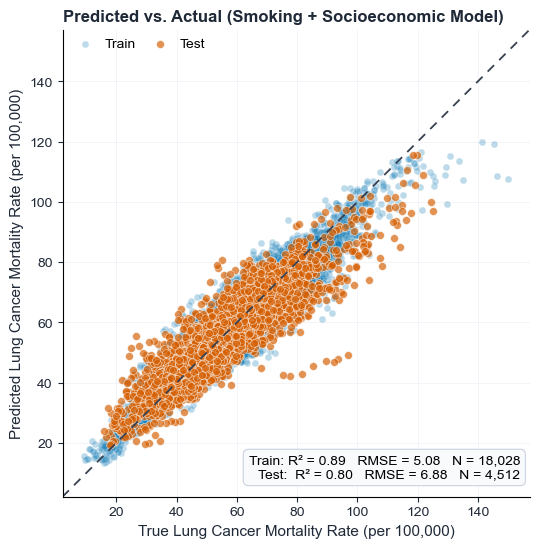

Figure 1: Scatter plot showing predicted vs. actual lung cancer mortality for the smoking and socioeconomic model.


In [13]:
# Create scatter plot
style_prediction_scatter(
    y_train=y_train,
    train_predictions=train_predictions,
    y_test=y_test,
    test_predictions=test_predictions,
    train_r2=r2_train,
    train_rmse=train_rmse,
    test_r2=r2_test,
    test_rmse=test_rmse,
    title='Predicted vs. Actual (Smoking + Socioeconomic Model)',
    filename='fig1_scatter_performance_smoking_ses.png',
    figure_note='Figure 1: Scatter plot showing predicted vs. actual lung cancer mortality for the smoking and socioeconomic model.'
)


### 4.6 Q-Q Plot: Test Residuals

Check whether the test residuals follow an approximately normal pattern.


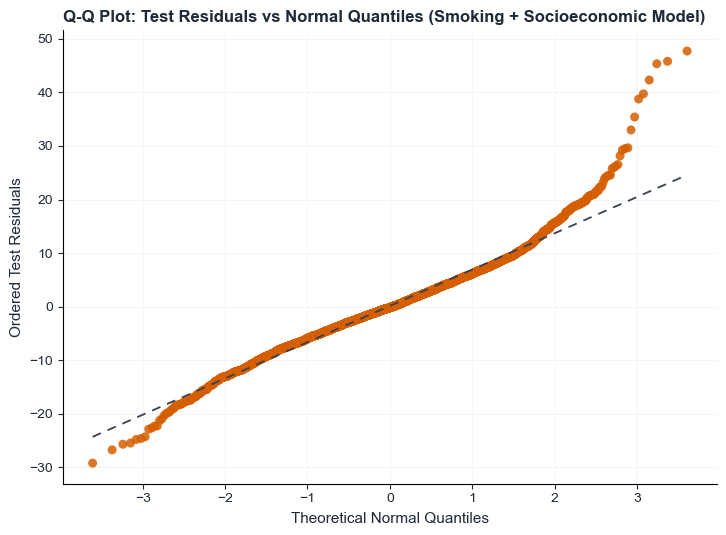

Figure 2: Residual normal Q-Q plot for the smoking and socioeconomic model.


In [14]:
# Create true residual normal Q-Q plot
style_residual_qq(
    y_test=y_test,
    test_predictions=test_predictions,
    title='Q-Q Plot: Test Residuals vs Normal Quantiles (Smoking + Socioeconomic Model)',
    filename='fig2_qq_plot_smoking_ses.png',
    figure_note='Figure 2: Residual normal Q-Q plot for the smoking and socioeconomic model.'
)


### 4.7 Permutation Importance

Calculate and visualize feature importance based on permutation.


In [15]:
# Calculate permutation importance
perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
)

perm_importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm_importance.importances_mean,
}).sort_values(by='Importance', ascending=False)

perm_importance_df_plot = perm_importance_df[~perm_importance_df['Feature'].isin(INTERPRETATION_EXCLUDE)].copy()

print(f'Permutation importance calculated for {len(perm_importance_df)} predictors')
print(f'Interpretation plot excludes: {sorted(INTERPRETATION_EXCLUDE)}')


Permutation importance calculated for 12 predictors
Interpretation plot excludes: ['is_post_2015']


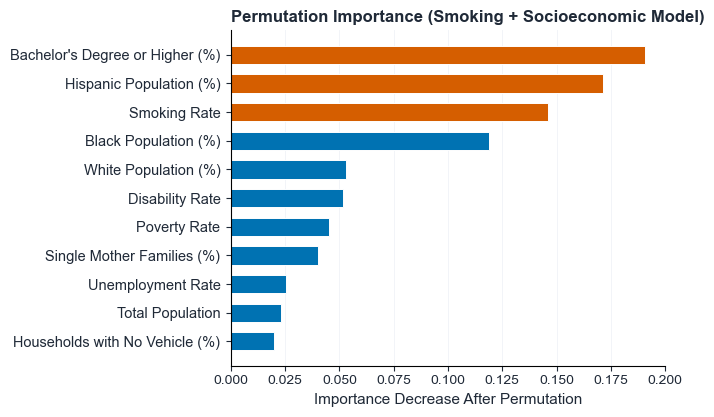

Figure 3: Permutation importance for the smoking and socioeconomic model.


In [16]:
# Plot permutation importance
style_horizontal_importance_bar(
    df_plot=perm_importance_df_plot,
    value_col='Importance',
    feature_col='Feature',
    title='Permutation Importance (Smoking + Socioeconomic Model)',
    xlabel='Importance Decrease After Permutation',
    filename='fig3_permutation_importance_smoking_ses.png',
    figure_note='Figure 3: Permutation importance for the smoking and socioeconomic model.',
    figsize=(DOUBLE_COL_WIDTH * 1.03, 4.3),
    top_n=len(perm_importance_df_plot)
)


### 4.8 SHAP Analysis

#### 4.8.1 SHAP Summary Plot


In [17]:
# Create SHAP explainer
print('Creating SHAP explainer...')
explainer = shap.TreeExplainer(best_model)

print('Computing SHAP values...')
shap_values = explainer.shap_values(X_test)

print(f'SHAP values computed for {X_test.shape[0]:,} test samples')


Creating SHAP explainer...
Computing SHAP values...
SHAP values computed for 4,512 test samples


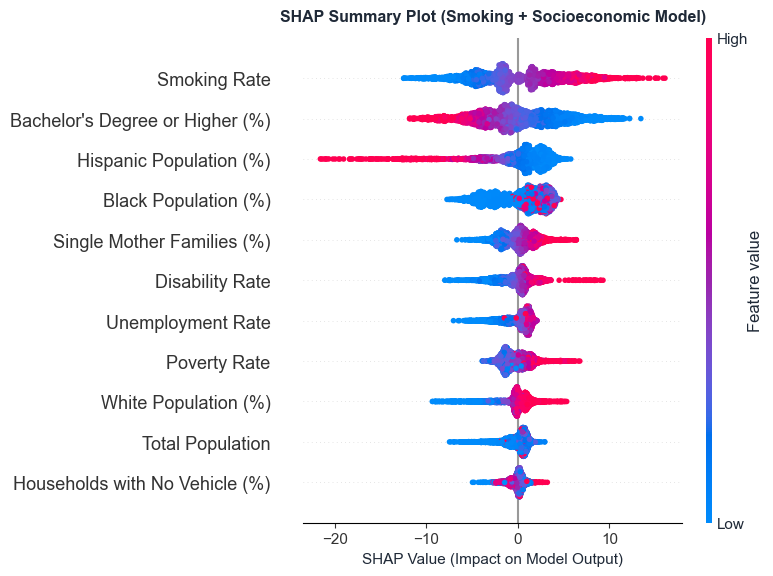

Figure 4: SHAP summary plot showing feature importance and impact direction for the smoking and socioeconomic model.


In [18]:
# SHAP summary plot (colored by feature value)
style_shap_summary_beeswarm(
    shap_values=shap_values,
    X_display=X_test,
    title='SHAP Summary Plot (Smoking + Socioeconomic Model)',
    filename='fig4_shap_summary_smoking_ses.png',
    figure_note='Figure 4: SHAP summary plot showing feature importance and impact direction for the smoking and socioeconomic model.',
    max_display=len(perm_importance_df_plot),
    figsize=(DOUBLE_COL_WIDTH * 1.02, 4.9)
)


#### 4.8.2 SHAP Bar Plot


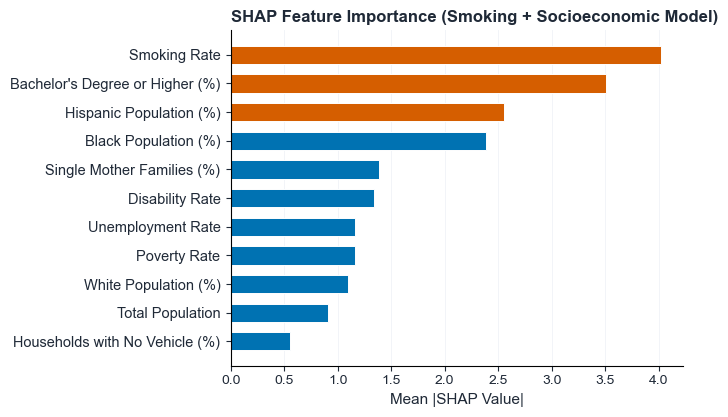

Figure 5: SHAP bar plot showing mean absolute SHAP values for the smoking and socioeconomic model.


In [19]:
# SHAP bar plot (mean absolute SHAP values)
style_shap_bar(
    shap_values=shap_values,
    feature_names=X_test.columns,
    title='SHAP Feature Importance (Smoking + Socioeconomic Model)',
    filename='fig5_shap_bar_smoking_ses.png',
    figure_note='Figure 5: SHAP bar plot showing mean absolute SHAP values for the smoking and socioeconomic model.',
    figsize=(DOUBLE_COL_WIDTH * 1.03, 4.3),
    max_display=len(perm_importance_df_plot)
)


#### 4.8.3 SHAP Dependence Plots

Show how the three strongest interpretation features affect predictions across their observed ranges.


In [20]:
# Get top 3 interpretation features by mean absolute SHAP value
shap_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=X_test.columns)
shap_importance_plot = shap_importance.drop(labels=list(INTERPRETATION_EXCLUDE), errors='ignore')
top_3_features = shap_importance_plot.nlargest(3).index.tolist()

print(f'Top 3 features for dependence plots: {top_3_features}')


Top 3 features for dependence plots: ['Smoking Rate', "Bachelor's Degree or Higher (%)", 'Hispanic Population (%)']


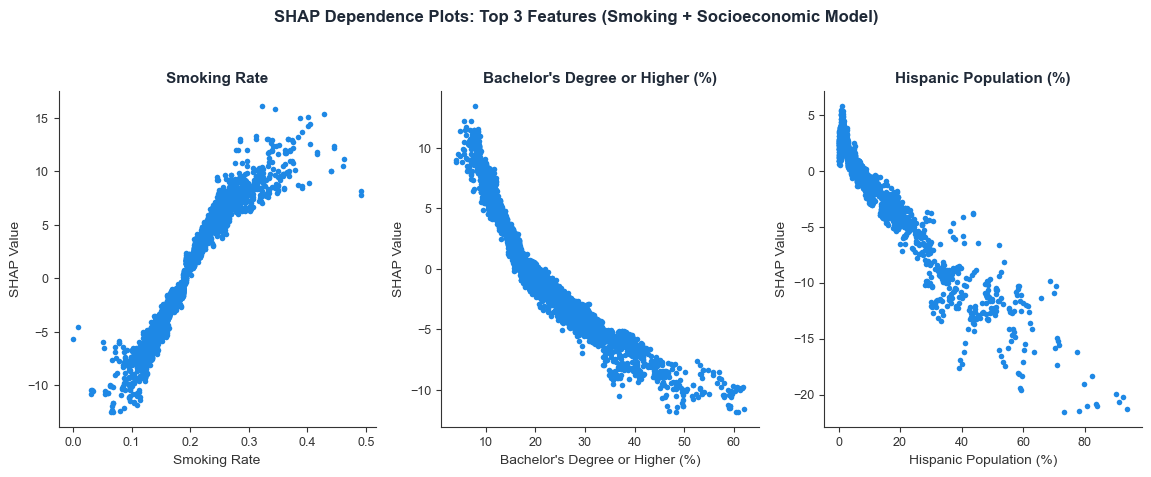

Figure 6: SHAP dependence plots showing non-linear relationships for the smoking and socioeconomic model.


In [21]:
# Create SHAP dependence plots for top 3 interpretation features
fig, axes = plt.subplots(1, 3, figsize=(DOUBLE_COL_WIDTH * 1.70, 4.6))

for idx, feature in enumerate(top_3_features):
    shap.dependence_plot(feature, shap_values, X_test, ax=axes[idx], show=False, interaction_index=None)
    axes[idx].set_title(feature, fontsize=FONT_SIZE, fontweight='bold', color=TITLE_COLOR)
    axes[idx].set_xlabel(feature, fontsize=FONT_SIZE - 1)
    axes[idx].set_ylabel('SHAP Value', fontsize=FONT_SIZE - 1)
    axes[idx].tick_params(axis='both', labelsize=FONT_SIZE - 2)

plt.suptitle('SHAP Dependence Plots: Top 3 Features (Smoking + Socioeconomic Model)',
             fontsize=FONT_SIZE + 1, fontweight='bold', color=TITLE_COLOR, y=1.03)
plt.tight_layout()
plt.savefig(f'{output_dir}fig6_shap_dependence_smoking_ses.png', dpi=DPI, bbox_inches='tight')
plt.show()

print('Figure 6: SHAP dependence plots showing non-linear relationships for the smoking and socioeconomic model.')


## 5. Summary

This notebook fits a single smoking and socioeconomic model using the same grouped XGBoost pipeline as notebook 09. The saved outputs can be compared directly against the 45-predictor model to test whether the atmospheric predictor block adds meaningful predictive value beyond smoking and socioeconomic structure.


In [22]:
print('=' * 70)
print('ANALYSIS COMPLETE')
print('=' * 70)
print(f'Outputs saved to: {output_dir}')
print('Saved files:')
for name in [
    'table1_metrics_smoking_ses.csv',
    'fig1_scatter_performance_smoking_ses.png',
    'fig2_qq_plot_smoking_ses.png',
    'fig3_permutation_importance_smoking_ses.png',
    'fig4_shap_summary_smoking_ses.png',
    'fig5_shap_bar_smoking_ses.png',
    'fig6_shap_dependence_smoking_ses.png',
]:
    print(f'  - {output_dir}{name}')


ANALYSIS COMPLETE
Outputs saved to: ../data/outputs/modeling/xgboost_smoking_ses/
Saved files:
  - ../data/outputs/modeling/xgboost_smoking_ses/table1_metrics_smoking_ses.csv
  - ../data/outputs/modeling/xgboost_smoking_ses/fig1_scatter_performance_smoking_ses.png
  - ../data/outputs/modeling/xgboost_smoking_ses/fig2_qq_plot_smoking_ses.png
  - ../data/outputs/modeling/xgboost_smoking_ses/fig3_permutation_importance_smoking_ses.png
  - ../data/outputs/modeling/xgboost_smoking_ses/fig4_shap_summary_smoking_ses.png
  - ../data/outputs/modeling/xgboost_smoking_ses/fig5_shap_bar_smoking_ses.png
  - ../data/outputs/modeling/xgboost_smoking_ses/fig6_shap_dependence_smoking_ses.png
